# Compare different optimality criteria

In [3]:
import sys
sys.path.append('/Users/jdiedrichsen/Python/MultiTaskBattery/MultiTaskBattery')
import numpy as np 
from numpy.linalg import inv,eig,eigh
import PcmPy as pcm
import matplotlib.pyplot as plt
import OptimalBattery.util as ut

In [4]:
N = 8 
U = np.random.normal(0,1,(N,10))
H = pcm.matrix.centering(N)


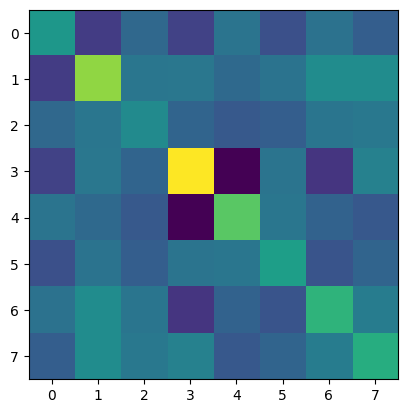

In [5]:
G = U @ U.T
Gc = H @ G @ H
plt.imshow(G)

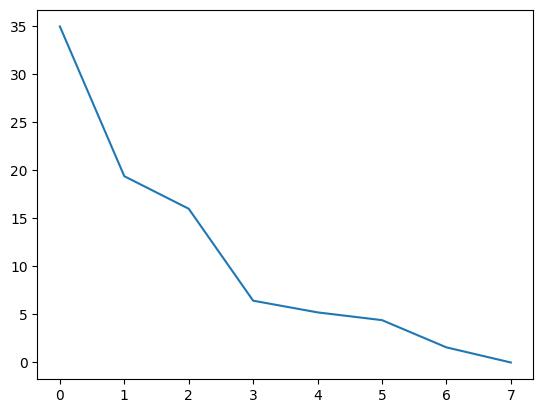

In [6]:
l,V = eigh(Gc)
l = l[::-1]
plt.plot(l)

In [7]:
li,Vi=eigh(inv(Gc))
print(li)
print(1./l)

[-6.31363114e-02  3.46826040e-03  4.57190683e-02  2.26677532e-01
  3.06938270e-01  5.40773125e-01  1.00206005e+00  3.00239975e+15]
[2.85829258e-02 5.15596642e-02 6.24727115e-02 1.55402846e-01
 1.91703171e-01 2.26803156e-01 6.35326584e-01 1.34161531e+15]


In [8]:
D=ut.build_combinations(G, strategy='random',n_iter=1000,n_tasks=4)
D

,offset,max_var,min_est,log_det,combination
0,0.000001,24.788864,1.000000e+06,-8.970043,"[2, 7, 4, 2]"
1,0.001000,24.791861,1.000195e+03,-2.062093,"[2, 7, 4, 2]"
2,0.100000,25.088861,1.019274e+01,2.562265,"[2, 7, 4, 2]"
3,0.000001,32.107720,1.000000e+06,-8.380934,"[4, 1, 1, 6]"
4,0.001000,32.110717,1.000140e+03,-1.473039,"[4, 1, 1, 6]"
...,...,...,...,...,...
2995,0.001000,32.755792,3.531049e-01,6.803822,"[3, 2, 7, 5]"
2996,0.100000,33.052792,3.480426e-01,6.838527,"[3, 2, 7, 5]"
2997,0.000001,25.765299,1.000000e+06,-8.887565,"[6, 6, 1, 0]"
2998,0.001000,25.768296,1.000187e+03,-1.979623,"[6, 6, 1, 0]"


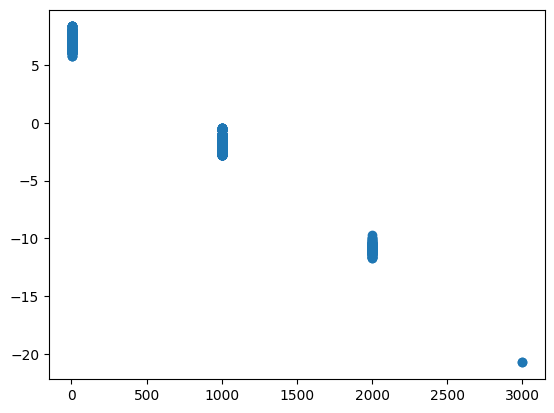

In [9]:
A= D[D.offset==0.001]
plt.scatter(A.min_est,A.log_det)